In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

In [2]:
# Load the dataset
file_path = '/home/f087s426/Downloads/Keywords Updated Data 01_08.xlsx'
data = pd.read_excel(file_path)

data.head()

,Keywords,Label
0,organic cotton,Environmental
1,recycled polyester,Environmental
2,natural dyes,Environmental
3,biodegradable materials,Environmental
4,sustainable fibers,Environmental


In [24]:
!pip -q install "numpy==1.23.5" "scipy==1.9.3" "gensim==4.3.2" "smart-open<7"


  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [3]:
import gensim, gensim.downloader as api

In [4]:
wv = api.load("word2vec-google-news-300")
wv.most_similar("innovation")[:5]


[('technological_innovation', 0.8202390670776367),
 ('innovations', 0.7408631443977356),
 ('innovate', 0.7123475074768066),
 ('innovating', 0.6502818465232849),
 ('Innovation', 0.6476377844810486)]

In [8]:
# from sklearn.base import BaseEstimator, TransformerMixin
# import numpy as np
# import re

# def simple_tokenizer(text):
#     return re.findall(r'\b\w+\b', text.lower())

# # Custom transformer for converting text to Word2Vec embeddings using a pre-trained model
# class Word2VecVectorizerPretrained(BaseEstimator, TransformerMixin):
#     def __init__(self, model):
#         self.model = model
#         self.dim = model.vector_size

#     def fit(self, X, y=None):

#         return self

#     def transform(self, X, y=None):
#         return np.array([
#             np.mean([self.model[word] for word in simple_tokenizer(doc) if word in self.model]
#                     or [np.zeros(self.dim)], axis=0)
#             for doc in X
#         ])

# X = data['Keywords']
# y = data['Label']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# # Creating a pipeline with Pre-trained Word2Vec Vectorizer and RandomForestClassifier
# pipeline_pretrained = Pipeline([
#     ('word2vec', Word2VecVectorizerPretrained(wv)),
#     ('classifier', RandomForestClassifier(class_weight='balanced'))
# ])
# # Training the model
# pipeline_pretrained.fit(X_train, y_train)

# # Predicting the test set
# predictions = pipeline_pretrained.predict(X_test)
# # Evaluating the best model
# accuracy = accuracy_score(y_test, predictions)
# report = classification_report(y_test, predictions)

# # Output the results
# print("Accuracy of Random Forest Model:", accuracy)
# print("\nClassification Report:\n", report)


In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np
import re

# Custom basic tokenizer function
def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

# Custom transformer for converting text to Word2Vec embeddings using a pre-trained model
class Word2VecVectorizerPretrained(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.dim = model.vector_size

    def fit(self, X, y=None):
        # No fitting needed, but the method must be defined
        return self

    def transform(self, X, y=None):
        return np.array([
            np.mean([self.model[word] for word in simple_tokenizer(doc) if word in self.model]
                    or [np.zeros(self.dim)], axis=0)
            for doc in X
        ])

# Data preparation
X = data['Keywords']
y = data['Label']

# Creating a pipeline with Pre-trained Word2Vec Vectorizer and RandomForestClassifier
pipeline_pretrained = Pipeline([
    ('word2vec', Word2VecVectorizerPretrained(wv)),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])

# Setting up K-Fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(pipeline_pretrained, X, y, cv=kfold)

# Output cross-validation results
print("K-Fold Cross-Validation Accuracy Scores:", cross_val_scores)
print("Mean K-Fold Cross-Validation Accuracy:", np.mean(cross_val_scores))

# Training the model on the entire dataset (optional for deployment purposes)
pipeline_pretrained.fit(X, y)

# Generating classification report based on cross-validation (average metrics)
predicted_y = cross_val_score(pipeline_pretrained, X, y, cv=kfold, scoring='accuracy')
print("\nCross-Validation Classification Report:\n")
print(f"Overall Accuracy: {np.mean(predicted_y):.2f}")


K-Fold Cross-Validation Accuracy Scores: [0.86666667 0.91525424 0.84745763 0.91525424 0.84745763]
Mean K-Fold Cross-Validation Accuracy: 0.8784180790960452

Cross-Validation Classification Report:

Overall Accuracy: 0.87


Accuracy: 0.8666666666666667
F1-score: 0.8667911609088079
ROC-AUC: 0.9677490106194341


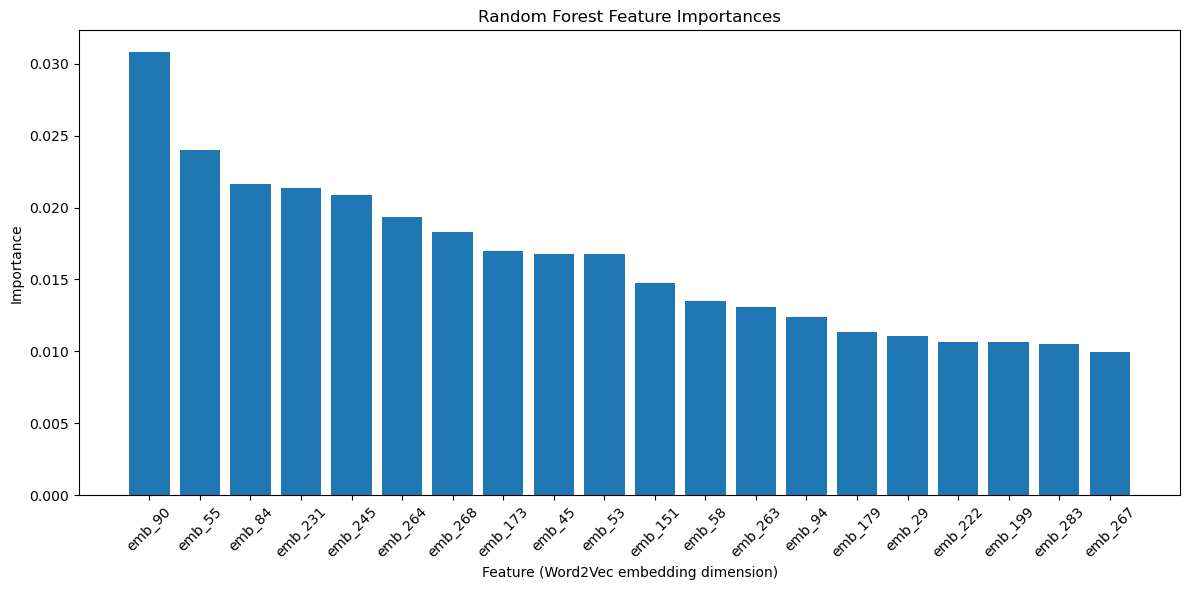

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import re
import shap
import matplotlib.pyplot as plt

# -----------------------
# Tokenizer
# -----------------------
def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

# -----------------------
# Word2Vec Transformer
# -----------------------
class Word2VecVectorizerPretrained(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.dim = model.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return np.array([
            np.mean([self.model[word] for word in simple_tokenizer(doc) if word in self.model]
                    or [np.zeros(self.dim)], axis=0)
            for doc in X
        ])

# -----------------------
# Data
# -----------------------
X = data['Keywords']  # Replace with your dataset
y = data['Label']

# Split for SHAP (train/test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------
# Random Forest Pipeline
# -----------------------
pipeline = Pipeline([
    ('word2vec', Word2VecVectorizerPretrained(wv)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Fit pipeline
pipeline.fit(X_train, y_train)

# -----------------------
# Evaluate
# -----------------------
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

X_test_transformed = pipeline.named_steps['word2vec'].transform(X_test)
y_pred = pipeline.named_steps['classifier'].predict(X_test_transformed)
y_prob = pipeline.named_steps['classifier'].predict_proba(X_test_transformed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class='ovr'))

# -----------------------
# SHAP Interpretability
# -----------------------
rf_model = pipeline.named_steps['classifier']

# Explain predictions using SHAP
#explainer = shap.TreeExplainer(rf_model)
#shap_values = explainer.shap_values(X_test_transformed)

# Summary plot (global feature importance)
#shap.summary_plot(shap_values, X_test_transformed, feature_names=[f'emb_{i}' for i in range(X_test_transformed.shape[1])])

# Optional: force plot for a single instance
#shap.force_plot(explainer.expected_value[0], shap_values[0][0], X_test_transformed[0], feature_names=[f'emb_{i}' for i in range(X_test_transformed.shape[1])])
import matplotlib.pyplot as plt
import numpy as np

# Extract model and transformed features
rf_model = pipeline.named_steps['classifier']
X_transformed = pipeline.named_steps['word2vec'].transform(X)

# Feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12,6))
plt.title("Random Forest Feature Importances")
plt.bar(range(20), importances[indices[:20]], align='center')  # top 20
plt.xticks(range(20), [f'emb_{i}' for i in indices[:20]], rotation=45)
plt.xlabel("Feature (Word2Vec embedding dimension)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [10]:
y.unique()

array(['Environmental', 'Social', 'Governance'], dtype=object)

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import numpy as np
import re

# Tokenizer
def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

# Word2Vec Transformer
class Word2VecVectorizerPretrained(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.dim = model.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return np.array([
            np.concatenate([
                np.mean(vectors, axis=0),
                np.max(vectors, axis=0),
                np.min(vectors, axis=0)
            ]) if len(vectors := [self.model[word] for word in simple_tokenizer(doc) if word in self.model]) > 0
            else np.zeros(self.dim * 3)
            for doc in X
         ])

# Data
X = data['Keywords']
y = data['Label']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ✅ ALL CLASSIFIERS
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=10,C=0.001,class_weight=None,solver='liblinear'),

    # KNN
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # Tree-based
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),

    # Boosting
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),

}

# KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Scoring
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_weighted',
    'roc_auc': 'roc_auc_ovr'
}

# Loop
for name, model in models.items():
    pipeline = Pipeline([
        ('word2vec', Word2VecVectorizerPretrained(wv)),
        ('classifier', model)
    ])

    scores = cross_validate(pipeline, X, y_encoded, cv=kfold, scoring=scoring)

    print(f"\n{name}")
    print("Mean Accuracy:", np.mean(scores['test_accuracy']))
    print("Mean F1-score:", np.mean(scores['test_f1']))
    print("Mean ROC-AUC:", np.mean(scores['test_roc_auc']))
    print("F1-score:", np.mean(scores['test_f1']), "+/-", np.std(scores['test_f1']))


Logistic Regression
Mean Accuracy: 0.6149152542372882
Mean F1-score: 0.5649546832963106
Mean ROC-AUC: 0.9444130512694514
F1-score: 0.5649546832963106 +/- 0.12301481270840228

KNN
Mean Accuracy: 0.7599435028248587
Mean F1-score: 0.7469148746281761
Mean ROC-AUC: 0.9419927562414477
F1-score: 0.7469148746281761 +/- 0.046368514580685784

Decision Tree
Mean Accuracy: 0.6453672316384181
Mean F1-score: 0.6418507989910772
Mean ROC-AUC: 0.7260683274607037
F1-score: 0.6418507989910772 +/- 0.0222005880855303

Random Forest
Mean Accuracy: 0.871638418079096
Mean F1-score: 0.8691588304192465
Mean ROC-AUC: 0.9678013924596309
F1-score: 0.8691588304192465 +/- 0.008367803756288008


/home/f087s426/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/f087s426/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/f087s426/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/f087s426/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent thi


AdaBoost
Mean Accuracy: 0.8445197740112995
Mean F1-score: 0.8438339914759192
Mean ROC-AUC: 0.9412605743267054
F1-score: 0.8438339914759192 +/- 0.019962272158700937

Gradient Boosting
Mean Accuracy: 0.8210169491525423
Mean F1-score: 0.8171532152458493
Mean ROC-AUC: 0.9468746612339695
F1-score: 0.8171532152458493 +/- 0.0422527511834013


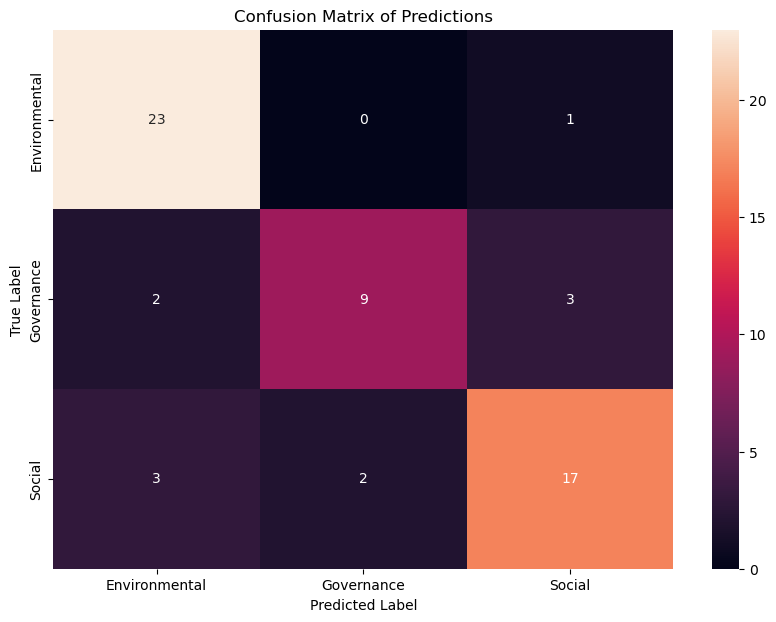

               precision    recall  f1-score   support

Environmental       0.82      0.96      0.88        24
   Governance       0.82      0.64      0.72        14
       Social       0.81      0.77      0.79        22

     accuracy                           0.82        60
    macro avg       0.82      0.79      0.80        60
 weighted avg       0.82      0.82      0.81        60



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Making predictions with the pipeline_pretrained model
pretrained_model_predictions = pipeline_pretrained.predict(X_test)

# Get indices of the test set from y_test
test_indices = y_test.index

# Extracting the test keywords and their corresponding true labels
test_keywords = X_test.loc[test_indices]
test_true_labels = y_test

# Creating a DataFrame for visualization
visualization_df = pd.DataFrame({
    'Keywords': test_keywords,
    'True Label': test_true_labels,
    'Predicted Label': pretrained_model_predictions
})

# Visualization code (e.g., plotting a confusion matrix, etc.) goes here
# This is an example of how you might visualize the results
# You can tailor this to your specific needs
plt.figure(figsize=(10, 7))
sns.heatmap(pd.crosstab(visualization_df['True Label'], visualization_df['Predicted Label']), annot=True, fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Predictions')
plt.show()
from sklearn.metrics import classification_report

print(classification_report(
    visualization_df['True Label'],
    visualization_df['Predicted Label']
))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Build confusion table
cm = pd.crosstab(visualization_df['True Label'],
                 visualization_df['Predicted Label'])

# Only scale fonts (not figure size)
sns.set_style("white")
sns.set_context("notebook", font_scale=1.6)   # titles/labels/ticks bigger

plt.figure(figsize=(10, 7))  # unchanged
ax = sns.heatmap(
    cm, annot=True, fmt="g", square=True,
    annot_kws={"size": 16, "weight": "bold"},  # cell numbers
    linewidths=.6, linecolor="white"
)

ax.set_xlabel("Predicted Label", fontsize=16, labelpad=10)
ax.set_ylabel("True Label", fontsize=16, labelpad=10)
ax.set_title("Confusion Matrix of Predictions", fontsize=20, pad=12)

# Ticks (keep horizontal like your example)
ax.tick_params(axis="both", labelsize=13)
plt.xticks(rotation=0)

# Colorbar tick size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


In [ ]:
from joblib import dump

# Save the pipeline_pretrained model to a file
dump(pipeline_pretrained, 'pretrained_word2vec_random_forest_model.joblib')


In [ ]:
#from google.colab import files
#files.download('/content/pretrained_word2vec_random_forest_model.joblib')


In [ ]:
from joblib import load

# Load the model from the file
pipeline_pretrained = load('pretrained_word2vec_random_forest_model.joblib')


In [ ]:
file_path = '/content/Topic 1 Keywords.xlsx'
file_path_two='/content/Topic 2 Keywords.xlsx'
file_path_three='/content/Topic 3 Keywords.xlsx'
file_path_four='/content/topic_4.xlsx'
import pandas as pd
# Load the Excel file
df = pd.read_excel(file_path,nrows=11)
df_two = pd.read_excel(file_path_two,nrows=11)
df_three = pd.read_excel(file_path_three,nrows=11)
df_four = pd.read_excel(file_path_four,nrows=11)

# Display the first few rows of the dataframe
print(df.head())
print()
print(df_two.head())
print()
print(df_three.head())
print()
print(df_four.head())

In [ ]:
X_new = df['Keywords']
# Use the model to make predictions on the new data
new_predictions = pipeline_pretrained.predict(X_new)

X_new_two = df_two['Keywords']
# Use the model to make predictions on the new data
new_predictions_two = pipeline_pretrained.predict(X_new_two)

X_new_three = df_three['Keywords']
# Use the model to make predictions on the new data
new_predictions_three = pipeline_pretrained.predict(X_new_three)

X_new_four = df_four['Keywords']
# Use the model to make predictions on the new data
new_predictions_four = pipeline_pretrained.predict(X_new_four)



In [ ]:
# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(new_predictions, columns=['Predictions'])
predictions_df_two = pd.DataFrame(new_predictions_two, columns=['Predictions'])
predictions_df_three = pd.DataFrame(new_predictions_three, columns=['Predictions'])
predictions_df_four = pd.DataFrame(new_predictions_four, columns=['Predictions'])

# Optionally, combine with the new data for a comprehensive view
result_df = df.copy()
result_df['Predictions'] = predictions_df

result_df_two = df_two.copy()
result_df_two['Predictions'] = predictions_df_two

result_df_three = df_three.copy()
result_df_three['Predictions'] = predictions_df_three

result_df_four = df_four.copy()
result_df_four['Predictions'] = predictions_df_four



# Save the predictions to a new Excel file
result_df.to_excel('/content/predictions1.xlsx', index=False)
result_df_two.to_excel('/content/predictions2.xlsx', index=False)
result_df_three.to_excel('/content/predictions3.xlsx', index=False)
result_df_four.to_excel('/content/predictions4.xlsx', index=False)


In [ ]:
print("Topic 1\n")
print(result_df.head(25))
print()
print("Topic 2\n")
print(result_df_two.head(25))
print()
print("Topic 3\n")
print(result_df_three.head(25))
print()
print("Topic 4\n")
print(result_df_four.head(25))

In [ ]:
# Frequency Distribution
frequency_distribution = predictions_df['Predictions'].value_counts()
print("Topic 1\n")
print(frequency_distribution)

frequency_distribution_two = predictions_df_two['Predictions'].value_counts()
print("\nTopic 2\n")
print(frequency_distribution_two)

frequency_distribution_three = predictions_df_three['Predictions'].value_counts()
print("\nTopic 3\n")
print(frequency_distribution_three)

frequency_distribution_four = predictions_df_four['Predictions'].value_counts()
print("\nTopic 4\n")
print(frequency_distribution_four)



In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

try:
    import seaborn as sns
    sns.reset_orig()
except Exception:
    pass
plt.rcdefaults()

data = {
    'Topic 1': {'Social': 5, 'Environmental': 4, 'Governance': 2},
    'Topic 2': {'Environmental': 8, 'Governance': 3, 'Social': 0},
    'Topic 3': {'Social': 7, 'Environmental': 4, 'Governance': 0},
    'Topic 4': {'Governance': 5, 'Environmental': 3, 'Social': 3}
}

colors = {'Social': 'skyblue', 'Environmental': 'lightgreen', 'Governance': 'lightcoral'}

fig, axs = plt.subplots(2, 2, figsize=(5.6, 5.6))
axs = axs.flatten()

def custom_autopct(pct):
    return f'{pct:.1f}%' if pct > 0 else ''

for i, (topic, distribution) in enumerate(data.items()):
    distribution_colors = [colors[k] for k in distribution.keys()]
    axs[i].pie(
        distribution.values(),
        autopct=lambda pct: custom_autopct(pct),
        startangle=140,
        colors=distribution_colors,
        textprops={'fontsize': 11, 'weight': 'semibold'},
        wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
    )
    maj = max(distribution, key=distribution.get)
    axs[i].set_title(f"{topic}\nLabel: {maj}", fontsize=12, weight='bold', pad=6)


fig.subplots_adjust(right=0.86, wspace=0.28, hspace=0.40)


labels = list(colors.keys())
handles = [Patch(facecolor=colors[l], edgecolor='black', label=l) for l in labels]
fig.legend(
    handles, labels,
    loc='center left',
    bbox_to_anchor=(0.88, 0.5),
    fontsize=11, frameon=True
)

plt.show()


In [ ]:
file_path = '/content/Company1_Keywords.xlsx'
df_company = pd.read_excel(file_path,nrows=11)
X_new = df_company['Keywords']
new_predictions_company = pipeline_pretrained.predict(X_new)


predictions_df_company = pd.DataFrame(new_predictions_company, columns=['Predictions'])

result_df_company = df_company.copy()
result_df_company['Predictions'] = predictions_df_company

result_df_company.to_excel('/content/predictions8.xlsx', index=False)
print("\nComany 1 Predictions")

print(result_df_company.head(11))
print("\nComany 1")

frequency_distribution_company = predictions_df_company['Predictions'].value_counts()
print(frequency_distribution_company)

In [ ]:
plt.figure(figsize=(5, 5))
frequency_distribution_company.plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Company 1 Prediction Distribution')
plt.ylabel('')

                      File_Name  Num_Chars  Num_Words
0           Envoy composite.txt       2181        299
1        Scottish sweatwear.txt       2069        297
2           Esquire limited.txt       2465        366
3          Hi tech appareal.txt       3679        504
4                 kenpark 6.txt       5074        674
..                          ...        ...        ...
81      Bay creaton limited.txt       1295        184
82  Dird composite textiles.txt       6885       1030
83              Hamim denim.txt        841         94
84               Renaissian.txt       3387        451
85                      Summary     353461      49205

[86 rows x 3 columns]


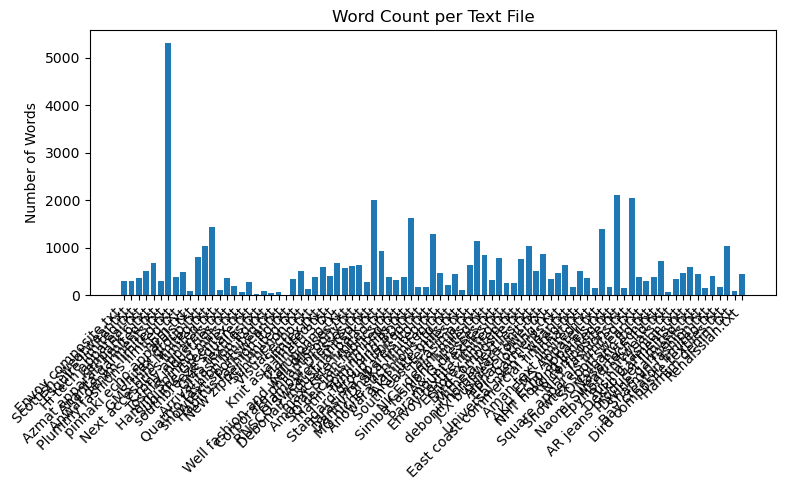

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Folder containing all text files
folder_path = "/home/f087s426/jupyter notebook/Textile_Dataset"  # change to your folder

stats = []

# Loop through all text files
for file in os.listdir(folder_path):
    if file.endswith(".txt"):
        file_path = os.path.join(folder_path, file)
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
            num_chars = len(text)
            num_words = len(text.split())
            stats.append({
                "File_Name": file,
                "Num_Chars": num_chars,
                "Num_Words": num_words
            })

# Create a DataFrame
df = pd.DataFrame(stats)

# Add summary statistics
summary = {
    "File_Name": "Summary",
    "Num_Chars": df["Num_Chars"].sum(),
    "Num_Words": df["Num_Words"].sum()
}
df = pd.concat([df, pd.DataFrame([summary])], ignore_index=True)

# Display stats
print(df)

# Save to CSV
# df.to_csv("text_files_stats.csv", index=False)
# print("Saved to text_files_stats.csv")

# Optional: Plot word count distribution
plt.figure(figsize=(8,5))
plt.bar(df["File_Name"][:-1], df["Num_Words"][:-1])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Words")
plt.title("Word Count per Text File")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1015092/2726744964.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="File_Name", y="Num_Words", data=df_plot, palette="viridis")


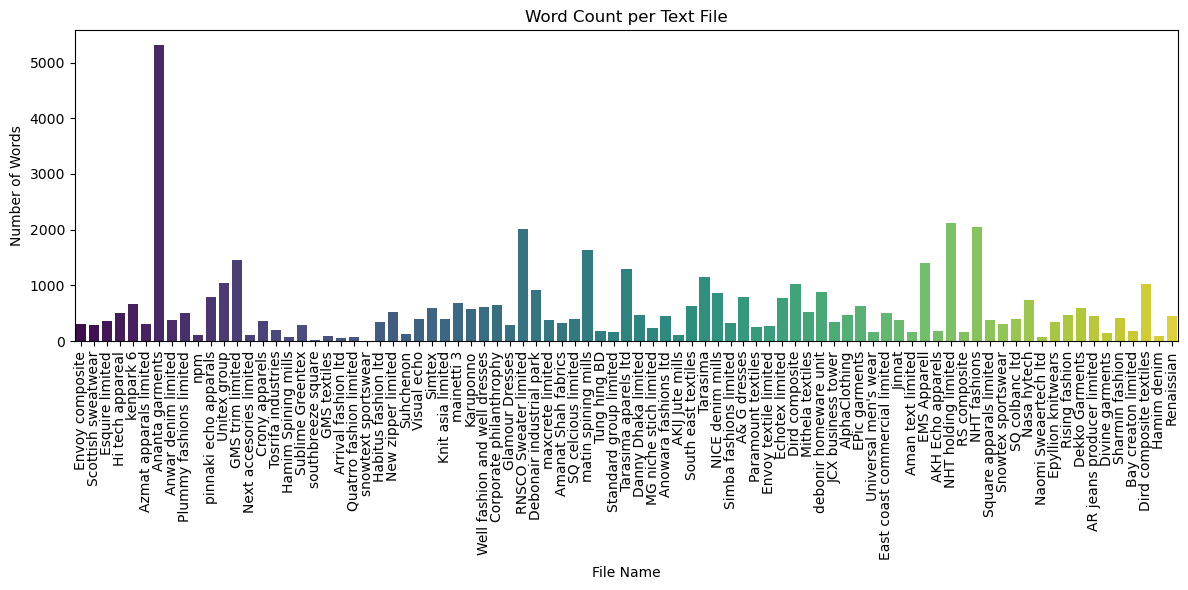

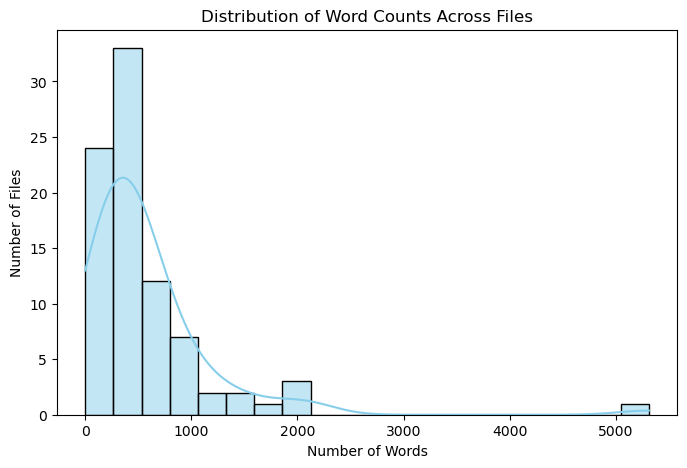

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


fig_folder = "/home/f087s426/jupyter notebook/Textile_Dataset/figures"
os.makedirs(fig_folder, exist_ok=True)
# Remove the summary row if present
df_plot = df[df["File_Name"] != "Summary"].copy()

# Remove '.txt' extension from File_Name
df_plot["File_Name"] = df_plot["File_Name"].str.replace(".txt", "", regex=False)

# -----------------------------
# 1. Word count per file - bar plot
# -----------------------------
plt.figure(figsize=(12,6))
sns.barplot(x="File_Name", y="Num_Words", data=df_plot, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel("Number of Words")
plt.xlabel("File Name")
plt.title("Word Count per Text File")
plt.tight_layout()
plt.savefig(os.path.join(fig_folder, "word_count_distribution.png"), dpi=300)
plt.show()

# -----------------------------
# 2. Character count per file - bar plot
# -----------------------------
# plt.figure(figsize=(12,6))
# sns.barplot(x="File_Name", y="Num_Chars", data=df_plot, palette="magma")
# plt.xticks(rotation=90)
# plt.ylabel("Number of Characters")
# plt.xlabel("File Name")
# plt.title("Character Count per Text File")
# plt.tight_layout()
# plt.show()

# -----------------------------
# 3. Distribution of words - histogram
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df_plot["Num_Words"], bins=20, kde=True, color="skyblue")
plt.xlabel("Number of Words")
plt.ylabel("Number of Files")
plt.title("Distribution of Word Counts Across Files")
plt.savefig(os.path.join(fig_folder, "word_count_distribution_hist.png"), dpi=300)
plt.show()

# -----------------------------
# 4. Boxplot for spotting outliers
# -----------------------------
# plt.figure(figsize=(6,5))
# sns.boxplot(y=df_plot["Num_Words"], color="lightgreen")
# plt.ylabel("Number of Words")
# plt.title("Boxplot of Word Counts Across Files")
# plt.show()